# Mirror-CFE: Chest X-Ray (No Finding vs. Infiltration)
**Methode:** Mirror-CFE nach Chowdhury et al. (2025)

## 1. Imports & Konfiguration

In [1]:
import os
import numpy as np
import pandas as pd
from glob import glob
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import GroupShuffleSplit

torch.manual_seed(2024)
np.random.seed(2024)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Gerät:', DEVICE)

CSV_PATH   = '../input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv'
BBOX_PATH  = '../input/datasets/organizations/nih-chest-xrays/data/BBox_List_2017.csv'
IMAGE_GLOB = '../input/datasets/organizations/nih-chest-xrays/data/images_*/images/*.png'
PTH_PATH   = '/kaggle/input/models/alexandernigg/resnet18-updated/pytorch/default/1/resnet18_xray_final.pth'

IMG_SIZE      = 224
BATCH_SIZE    = 16
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
CLASS_NAMES   = {0: 'No Finding', 1: 'Infiltration'}

print('CSV    vorhanden:', os.path.exists(CSV_PATH))
print('BBox   vorhanden:', os.path.exists(BBOX_PATH))
print('Modell vorhanden:', os.path.exists(PTH_PATH))

Gerät: cuda
CSV    vorhanden: True
BBox   vorhanden: True
Modell vorhanden: True


## 2. Datensatz laden

In [2]:
all_xray_df = pd.read_csv(CSV_PATH)
all_xray_df['Patient Age'] = all_xray_df['Patient Age'].astype(str).str.rstrip('Y').astype(int)
all_image_paths = {os.path.basename(x): x for x in glob(IMAGE_GLOB)}
all_xray_df['path'] = all_xray_df['Image Index'].map(all_image_paths.get)

def assign_binary_label(finding: str):
    if finding == 'No Finding':
        return 0
    elif 'Infiltration' in finding:
        return 1
    return None

all_xray_df['binary_label'] = all_xray_df['Finding Labels'].map(assign_binary_label)
all_xray_df = all_xray_df.dropna(subset=['binary_label', 'path']).copy()
all_xray_df['binary_label'] = all_xray_df['binary_label'].astype(int)

counts = all_xray_df['binary_label'].value_counts().rename({0: 'No Finding', 1: 'Infiltration'})
print('Klassenverteilung:')
print(counts)

Klassenverteilung:
binary_label
No Finding      60361
Infiltration    19894
Name: count, dtype: int64


## 3. Bounding Boxes laden

In [3]:
bbox_df = pd.read_csv(BBOX_PATH)
bbox_df = bbox_df.rename(columns={'Bbox [x': 'x', 'y': 'y', 'w': 'w', 'h]': 'h'})[
    ['Image Index', 'Finding Label', 'x', 'y', 'w', 'h']]
infiltrate_bbox = bbox_df[bbox_df['Finding Label'] == 'Infiltrate'].copy()
scale = IMG_SIZE / 1024.0
for col in ['x', 'y', 'w', 'h']:
    infiltrate_bbox[col] = infiltrate_bbox[col] * scale
bbox_lookup = infiltrate_bbox.groupby('Image Index').first()[['x', 'y', 'w', 'h']].to_dict('index')
print(f'Infiltrate BBoxes: {len(bbox_lookup)} Bilder')

Infiltrate BBoxes: 123 Bilder


## 4. Train/Test Split (patientenbasiert)

In [4]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, temp_idx = next(splitter.split(all_xray_df, groups=all_xray_df['Patient ID']))
train_df = all_xray_df.iloc[train_idx].reset_index(drop=True)
temp_df  = all_xray_df.iloc[temp_idx].reset_index(drop=True)
splitter2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
val_idx, test_idx = next(splitter2.split(temp_df, groups=temp_df['Patient ID']))
valid_df = temp_df.iloc[val_idx].reset_index(drop=True)
test_df  = temp_df.iloc[test_idx].reset_index(drop=True)
assert len(set(train_df['Patient ID']) & set(test_df['Patient ID'])) == 0
print(f'Train: {len(train_df)}  Val: {len(valid_df)}  Test: {len(test_df)}')

Train: 56768  Val: 11926  Test: 11561


## 5. DataLoader

In [5]:
eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class XRayDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row['path']).convert('RGB')
        label = torch.tensor(row['binary_label'], dtype=torch.float32)
        fname = row['Image Index']
        if self.transform:
            image = self.transform(image)
        return image, label, fname

test_dataset = XRayDataset(test_df, transform=eval_transforms)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=2, pin_memory=False)
print(f'Test-Batches: {len(test_loader)}')

Test-Batches: 723


## 6. Modell laden

In [6]:
from collections import OrderedDict
from functools import partial

class Conv2dAuto(nn.Conv2d):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.padding = (self.kernel_size[0] // 2, self.kernel_size[1] // 2)

conv3x3 = partial(Conv2dAuto, kernel_size=3, bias=False)

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.in_channels  = in_channels
        self.out_channels = out_channels
        self.blocks   = nn.Identity()
        self.shortcut = nn.Identity()
    def forward(self, x):
        residual = self.shortcut(x) if self.should_apply_shortcut else x
        x = self.blocks(x)
        x += residual
        return x
    @property
    def should_apply_shortcut(self):
        return self.in_channels != self.out_channels

class ResNetResidualBlock(ResidualBlock):
    def __init__(self, in_channels, out_channels, expansion=1,
                 downsampling=1, conv=conv3x3, *args, **kwargs):
        super().__init__(in_channels, out_channels)
        self.expansion    = expansion
        self.downsampling = downsampling
        self.conv         = conv
        self.shortcut = (
            nn.Sequential(OrderedDict({
                'conv': nn.Conv2d(self.in_channels, self.expanded_channels,
                                  kernel_size=1, stride=self.downsampling, bias=False),
                'bn':   nn.BatchNorm2d(self.expanded_channels)
            }))
            if self.should_apply_shortcut else None
        )
    @property
    def expanded_channels(self):
        return self.out_channels * self.expansion
    @property
    def should_apply_shortcut(self):
        return self.in_channels != self.expanded_channels

def conv_bn(in_channels, out_channels, conv, *args, **kwargs):
    return nn.Sequential(OrderedDict({
        'conv': conv(in_channels, out_channels, *args, **kwargs),
        'bn':   nn.BatchNorm2d(out_channels)
    }))

class ResNetBasicBlock(ResNetResidualBlock):
    expansion = 1
    def __init__(self, in_channels, out_channels, activation=nn.ReLU, *args, **kwargs):
        super().__init__(in_channels, out_channels, *args, **kwargs)
        self.blocks = nn.Sequential(
            conv_bn(self.in_channels, self.out_channels,
                    conv=self.conv, bias=False, stride=self.downsampling),
            activation(),
            conv_bn(self.out_channels, self.expanded_channels,
                    conv=self.conv, bias=False),
        )

class ResNetLayer(nn.Module):
    def __init__(self, in_channels, out_channels, block=ResNetBasicBlock,
                 n=1, *args, **kwargs):
        super().__init__()
        downsampling = 2 if in_channels != out_channels else 1
        self.blocks = nn.Sequential(
            block(in_channels, out_channels, *args, **kwargs,
                  downsampling=downsampling),
            *[block(out_channels * block.expansion, out_channels,
                    downsampling=1, *args, **kwargs) for _ in range(n - 1)]
        )
    def forward(self, x):
        return self.blocks(x)

class ResNetEncoder(nn.Module):
    def __init__(self, in_channels=3, blocks_sizes=(64, 128, 256, 512),
                 depths=(2, 2, 2, 2), activation=nn.ReLU,
                 block=ResNetBasicBlock, *args, **kwargs):
        super().__init__()
        self.blocks_sizes = blocks_sizes
        self.gate = nn.Sequential(
            nn.Conv2d(in_channels, blocks_sizes[0], kernel_size=7,
                      stride=2, padding=3, bias=False),
            nn.BatchNorm2d(blocks_sizes[0]),
            activation(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )
        self.in_out_block_sizes = list(zip(blocks_sizes, blocks_sizes[1:]))
        self.blocks = nn.ModuleList([
            ResNetLayer(blocks_sizes[0], blocks_sizes[0], n=depths[0],
                        activation=activation, block=block, *args, **kwargs),
            *[ResNetLayer(in_ch * block.expansion, out_ch, n=n,
                          activation=activation, block=block, *args, **kwargs)
              for (in_ch, out_ch), n in zip(self.in_out_block_sizes, depths[1:])]
        ])
    def forward(self, x):
        x = self.gate(x)
        for block in self.blocks:
            x = block(x)
        return x

class ResNetDecoder(nn.Module):
    def __init__(self, in_features, n_classes):
        super().__init__()
        self.avg     = nn.AdaptiveAvgPool2d((1, 1))
        self.decoder = nn.Linear(in_features, n_classes)
    def forward(self, x):
        x = self.avg(x)
        x = x.view(x.size(0), -1)
        x = self.decoder(x)
        return x

class ResNet(nn.Module):
    def __init__(self, in_channels, n_classes, *args, **kwargs):
        super().__init__()
        self.encoder = ResNetEncoder(in_channels, *args, **kwargs)
        self.decoder = ResNetDecoder(
            self.encoder.blocks[-1].blocks[-1].expanded_channels, n_classes
        )
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

def build_model():
    return ResNet(in_channels=3, n_classes=2,
                  block=ResNetBasicBlock, depths=[2, 2, 2, 2])

checkpoint = torch.load(PTH_PATH, map_location=DEVICE, weights_only=False)
model      = build_model().to(DEVICE)
state      = checkpoint.get('model_state_dict', checkpoint)
model.load_state_dict(state)
model.eval()
print('Modell geladen ✓')
print(f'Test-AUC:      {checkpoint.get("test_auc", "N/A")}')
print(f'Test-Accuracy: {checkpoint.get("test_accuracy", "N/A")}')
with torch.no_grad():
    dummy = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    print('Output-Shape:', model(dummy).shape)

Modell geladen ✓
Test-AUC:      0.7513
Test-Accuracy: 0.6863
Output-Shape: torch.Size([2, 2])


## 7. Mirror-CFE Kernfunktionen

In [7]:
def extract_feature_maps(model, images):
    """Feature Maps aus dem letzten Encoder-Block. Rückgabe: (B, 512, 7, 7)"""
    feat = []
    hook = model.encoder.blocks[-1].register_forward_hook(
        lambda m, i, o: feat.append(o)
    )
    with torch.no_grad():
        _ = model(images)
    hook.remove()
    return feat[0]

def get_boundary_params(model):
    """
    Entscheidungsgrenze: Wm = W[1] - W[0], bm = b[1] - b[0]
    Zeigt in Richtung Klasse 1 (Zielklasse).
    Identisch für beide Modelle.
    """
    W  = model.decoder.decoder.weight.data   # (2, 512)
    b  = model.decoder.decoder.bias.data     # (2,)
    Wm = W[1] - W[0]                         # (512,)  ← WICHTIG: immer W[1]-W[0]
    bm = b[1] - b[0]                         # scalar
    return Wm, bm

def position_function(zs_batch, Wm, bm, k):
    """Paper Eq. 1: P(zs, Wm, bm, k) = zs - 2k*(Wm^T*zs+bm)*Ŵm"""
    B, C, H, W = zs_batch.shape
    W_hat   = Wm / (Wm.norm() + 1e-8)
    zs_flat = zs_batch.view(B, C, -1)
    dot     = (Wm.view(1, C, 1) * zs_flat).sum(dim=1, keepdim=True)
    scalar  = dot + bm.item()
    delta   = 2 * k * scalar * W_hat.view(1, C, 1)
    return (zs_flat - delta).view(B, C, H, W)

def refine_with_lbfgs(model, zr_init, source_labels, cfe_labels,
                      orig_probs_2cls, num_iterations=20):
    """L-BFGS Verfeinerung bis der Decoder die Zielklasse ausgibt."""
    swapped = orig_probs_2cls.clone().detach()
    idx     = torch.arange(len(cfe_labels))
    src     = source_labels.view(-1)
    cfe     = cfe_labels.view(-1)
    tmp               = swapped[idx, cfe].clone()
    swapped[idx, cfe] = swapped[idx, src]
    swapped[idx, src] = tmp

    z         = Variable(zr_init.clone().detach(), requires_grad=True)
    optimizer = torch.optim.LBFGS([z], lr=0.1)

    def closure():
        optimizer.zero_grad()
        pooled = F.adaptive_avg_pool2d(z, (1, 1))
        flat   = torch.flatten(pooled, 1)
        logits = model.decoder.decoder(flat)
        probs  = torch.softmax(logits, dim=1)
        loss   = torch.norm(probs - swapped) ** 2
        loss.backward()
        return loss

    for _ in range(num_iterations):
        optimizer.step(closure)
    return z

def compute_mirror_cfe(model, images, device, num_iterations=20):
    """Vollständige Mirror-CFE Pipeline. Identisch für beide Modelle."""
    model.eval()
    images = images.to(device)
    with torch.no_grad():
        logits        = model(images)
        probs         = torch.softmax(logits, dim=1)
        orig_probs    = probs[:, 1]              # P(Klasse 1)
        source_labels = logits.argmax(dim=1)
        cfe_labels    = 1 - source_labels

    zs     = extract_feature_maps(model, images)
    Wm, bm = get_boundary_params(model)
    Wm, bm = Wm.to(device), bm.to(device)

    with torch.no_grad():
        zr_geometric = position_function(zs.clone(), Wm, bm, k=1.0)

    mirror_fv = refine_with_lbfgs(
        model, zr_geometric, source_labels, cfe_labels,
        probs.clone(), num_iterations=num_iterations
    )
    return mirror_fv, cfe_labels, source_labels, orig_probs

print('Mirror-CFE Funktionen definiert ✓')

Mirror-CFE Funktionen definiert ✓


## 8. Hilfsfunktionen

In [8]:
def denormalise(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

def predict_from_features(model, feature_maps):
    """Gibt P(Klasse 1) zurück."""
    with torch.no_grad():
        pooled = F.adaptive_avg_pool2d(feature_maps, (1, 1))
        flat   = torch.flatten(pooled, 1)
        logits = model.decoder.decoder(flat)
        probs  = torch.softmax(logits, dim=1)[:, 1]
    return probs

def draw_bbox_on_ax(ax, bbox_dict, image_name, color='yellow', linewidth=2):
    if image_name not in bbox_dict:
        return False
    b = bbox_dict[image_name]
    rect = patches.Rectangle(
        (b['x'], b['y']), b['w'], b['h'],
        linewidth=linewidth, edgecolor=color,
        facecolor='none', linestyle='--'
    )
    ax.add_patch(rect)
    ax.text(b['x'], b['y'] - 4, 'GT BBox',
            color=color, fontsize=7, fontweight='bold',
            bbox=dict(facecolor='black', alpha=0.4, pad=1))
    return True

print('Hilfsfunktionen definiert ✓')

Hilfsfunktionen definiert ✓


## 9. Visualisierungsfunktion (Paper-orientiert)

In [9]:
def generate_kfe_transitions(zs, zr, k_steps=None):
    """
    KFE-Übergänge: lineare Interpolation von zs nach zr.
    k=0.0 → zs (Quelle), k=0.5 → Grenze, k=1.0 → zr (Reflexion)
    """
    if k_steps is None:
        k_steps = [0.0, 0.25, 0.5, 0.6, 0.75, 1.0]
    transitions = []
    with torch.no_grad():
        for k in k_steps:
            zk = (1 - k) * zs + k * zr.detach()
            transitions.append(zk)
    return transitions, k_steps


def visualise_cfe(model, images, labels, fnames,
                  mirror_fv, cfe_labels, source_labels,
                  orig_probs, bbox_lookup, class_names,
                  bbox_class_idx=1, bbox_color='yellow',
                  n_samples=4, save_path='mirror_cfe.png'):
    """
    Visualisierung orientiert am Paper (Fig. 3 + Supplement Abschnitt 10.3):

    Zeile pro Sample:
      Spalte 1    : Originalbild + GT BBox (falls vorhanden)
      Spalten 2-7 : KFE-Übergang k=0.0 → k=1.0 (Feature-Map Heatmaps)
      Spalte 8    : Konfidenz-Journey Plot (Paper Abschnitt 10.3)
    """
    model.eval()
    images = images.to(DEVICE)
    n      = min(n_samples, images.size(0))

    # Feature Maps der Quellbilder
    source_fv = extract_feature_maps(model, images[:n])

    # KFE Übergänge generieren
    k_steps = [0.0, 0.25, 0.5, 0.6, 0.75, 1.0]
    transitions, ks = generate_kfe_transitions(source_fv, mirror_fv[:n], k_steps)

    # Konfidenz bei jedem k
    conf_matrix = []
    for zk in transitions:
        p = predict_from_features(model, zk).cpu().numpy()
        conf_matrix.append(p)

    # CFE Wahrscheinlichkeiten (k=1.0)
    with torch.no_grad():
        cfe_logits = model.decoder.decoder(
            torch.flatten(F.adaptive_avg_pool2d(mirror_fv[:n], (1,1)), 1)
        )
        cfe_probs = torch.softmax(cfe_logits, dim=1)[:, 1].cpu().numpy()

    orig_probs_np = orig_probs[:n].detach().cpu().numpy()

    n_cols = 2 + len(k_steps)   # Bild + k-Schritte + Konfidenz-Plot
    fig    = plt.figure(figsize=(n_cols * 2.8, n * 3.8))
    gs     = gridspec.GridSpec(n, n_cols, figure=fig, hspace=0.6, wspace=0.25)

    k_labels = ['k=0\n(Quelle)', 'k=0.25', 'k=0.5\n(Grenze)',
                 'k=0.6\n(1. CFE)', 'k=0.75', 'k=1.0\n(Reflexion)']

    for i in range(n):
        img_np   = denormalise(images[i].cpu()).permute(1, 2, 0).numpy()
        src_lbl  = source_labels[i].item()
        cfe_lbl  = cfe_labels[i].item()
        true_lbl = int(labels[i])
        fname    = fnames[i]
        flipped  = int(cfe_probs[i] >= 0.5) == cfe_lbl
        has_bbox = fname in bbox_lookup

        # ── Spalte 1: Originalbild + BBox ─────────────────────────────────────
        ax0 = fig.add_subplot(gs[i, 0])
        ax0.imshow(img_np)
        if has_bbox and true_lbl == bbox_class_idx:
            draw_bbox_on_ax(ax0, bbox_lookup, fname, color=bbox_color)
        pred_col = 'limegreen' if src_lbl == true_lbl else 'tomato'
        ax0.set_title(
            f'Original\nWahr: {class_names[true_lbl]}\n'
            f'Pred: {class_names[src_lbl]}\n({orig_probs_np[i]:.1%})',
            fontsize=7, color=pred_col)
        ax0.axis('off')

        # ── Spalten 2-7: KFE Feature Map Heatmaps ─────────────────────────────
        for j, (zk, k_lbl) in enumerate(zip(transitions, k_labels)):
            ax = fig.add_subplot(gs[i, j + 1])

            # Mittlere Aktivierung über 512 Kanäle → 7x7 Heatmap
            hmap = zk[i].detach().cpu().mean(0).numpy()
            hmap = (hmap - hmap.min()) / (hmap.max() + 1e-8)

            ax.imshow(hmap, cmap='hot', interpolation='bilinear',
                      vmin=0, vmax=1)

            # Konfidenz als Text auf der Heatmap
            p_k = conf_matrix[j][i]
            pred_at_k = class_names[int(p_k >= 0.5)]
            cross = p_k >= 0.5 and cfe_lbl == 1
            cross_col = 'cyan' if (int(p_k >= 0.5) == cfe_lbl) else 'white'

            ax.text(0.5, 0.02, f'P(Kl.1)={p_k:.2f}\n{pred_at_k}',
                    transform=ax.transAxes, ha='center', va='bottom',
                    fontsize=6, color=cross_col,
                    bbox=dict(facecolor='black', alpha=0.5, pad=1))

            # Grenze markieren
            if abs(k_steps[j] - 0.5) < 0.01:
                for spine in ax.spines.values():
                    spine.set_edgecolor('cyan')
                    spine.set_linewidth(2)
            # 1. CFE markieren
            if k_steps[j] == 0.6:
                flip_col = 'limegreen' if flipped else 'tomato'
                for spine in ax.spines.values():
                    spine.set_edgecolor(flip_col)
                    spine.set_linewidth(2)

            ax.set_title(k_lbl, fontsize=6.5)
            ax.set_xticks([])
            ax.set_yticks([])

        # ── Spalte 8: Konfidenz-Journey Plot ──────────────────────────────────
        ax_conf = fig.add_subplot(gs[i, -1])
        confs_i = [conf_matrix[j][i] for j in range(len(ks))]

        ax_conf.plot(ks, confs_i, 'o-', color='steelblue', lw=2, ms=4,
                     label=f'P({class_names[1]})')
        ax_conf.axhline(0.5, color='k', ls='--', lw=1, label='Grenze')
        ax_conf.axvline(0.5, color='cyan', ls=':', lw=1, label='k=0.5')

        # 1. CFE Punkt markieren
        for j, (k, p) in enumerate(zip(ks, confs_i)):
            if int(p >= 0.5) == cfe_lbl:
                ax_conf.scatter([k], [p], color='limegreen', s=60, zorder=5,
                                label='1. CFE')
                break

        ax_conf.set_xlim(-0.05, 1.05)
        ax_conf.set_ylim(-0.05, 1.1)
        ax_conf.set_xlabel('k', fontsize=7)
        ax_conf.set_ylabel('Konfidenz', fontsize=7)
        ax_conf.tick_params(labelsize=6)
        ax_conf.legend(fontsize=5.5, loc='upper left')
        flip_col = 'limegreen' if flipped else 'tomato'
        flip_txt = '✓ Gekippt' if flipped else '✗ Nicht gekippt'
        ax_conf.set_title(
            f'Konfidenz-Journey\n{class_names[src_lbl]} → {class_names[cfe_lbl]}\n{flip_txt}',
            fontsize=7, color=flip_col)

    plt.suptitle(
        'Mirror-CFE — KFE Übergang (k=0 bis k=1)\n'
        'Cyan = Grenze (k=0.5) | Grün/Rot = 1. CFE Punkt',
        fontsize=11, y=1.01)

    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Gespeichert → {save_path}')

print('Visualisierungsfunktion definiert ✓')

Visualisierungsfunktion definiert ✓


## 10. Sanity Check — Flip Rate

In [10]:
sample_images, sample_labels, sample_fnames = next(iter(test_loader))

mirror_fv, cfe_labels, source_labels, orig_probs = compute_mirror_cfe(
    model, sample_images, DEVICE, num_iterations=20
)

cfe_probs = predict_from_features(model, mirror_fv).cpu()
cfe_preds = (cfe_probs >= 0.5).long()
flip_rate = (cfe_preds == cfe_labels.cpu()).float().mean()

print(f'Batch-Größe   : {len(sample_labels)}')
print(f'Flip Rate     : {flip_rate:.2%}  (Ziel: >80%)')
print(f'Quellvorhers. : {source_labels.tolist()}')
print(f'CFE-Vorhers.  : {cfe_preds.tolist()}')
print(f'Zielklassen   : {cfe_labels.tolist()}')
bbox_count = sum(1 for f in sample_fnames if f in bbox_lookup)
print(f'Bilder mit BBox: {bbox_count}/{len(sample_fnames)}')
if flip_rate < 0.8:
    print('\n⚠ Flip Rate niedrig — num_iterations auf 50 erhöhen')

Batch-Größe   : 16
Flip Rate     : 100.00%  (Ziel: >80%)
Quellvorhers. : [1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1]
CFE-Vorhers.  : [0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0]
Zielklassen   : [0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0]
Bilder mit BBox: 0/16


## 11. Visualisierung ausführen

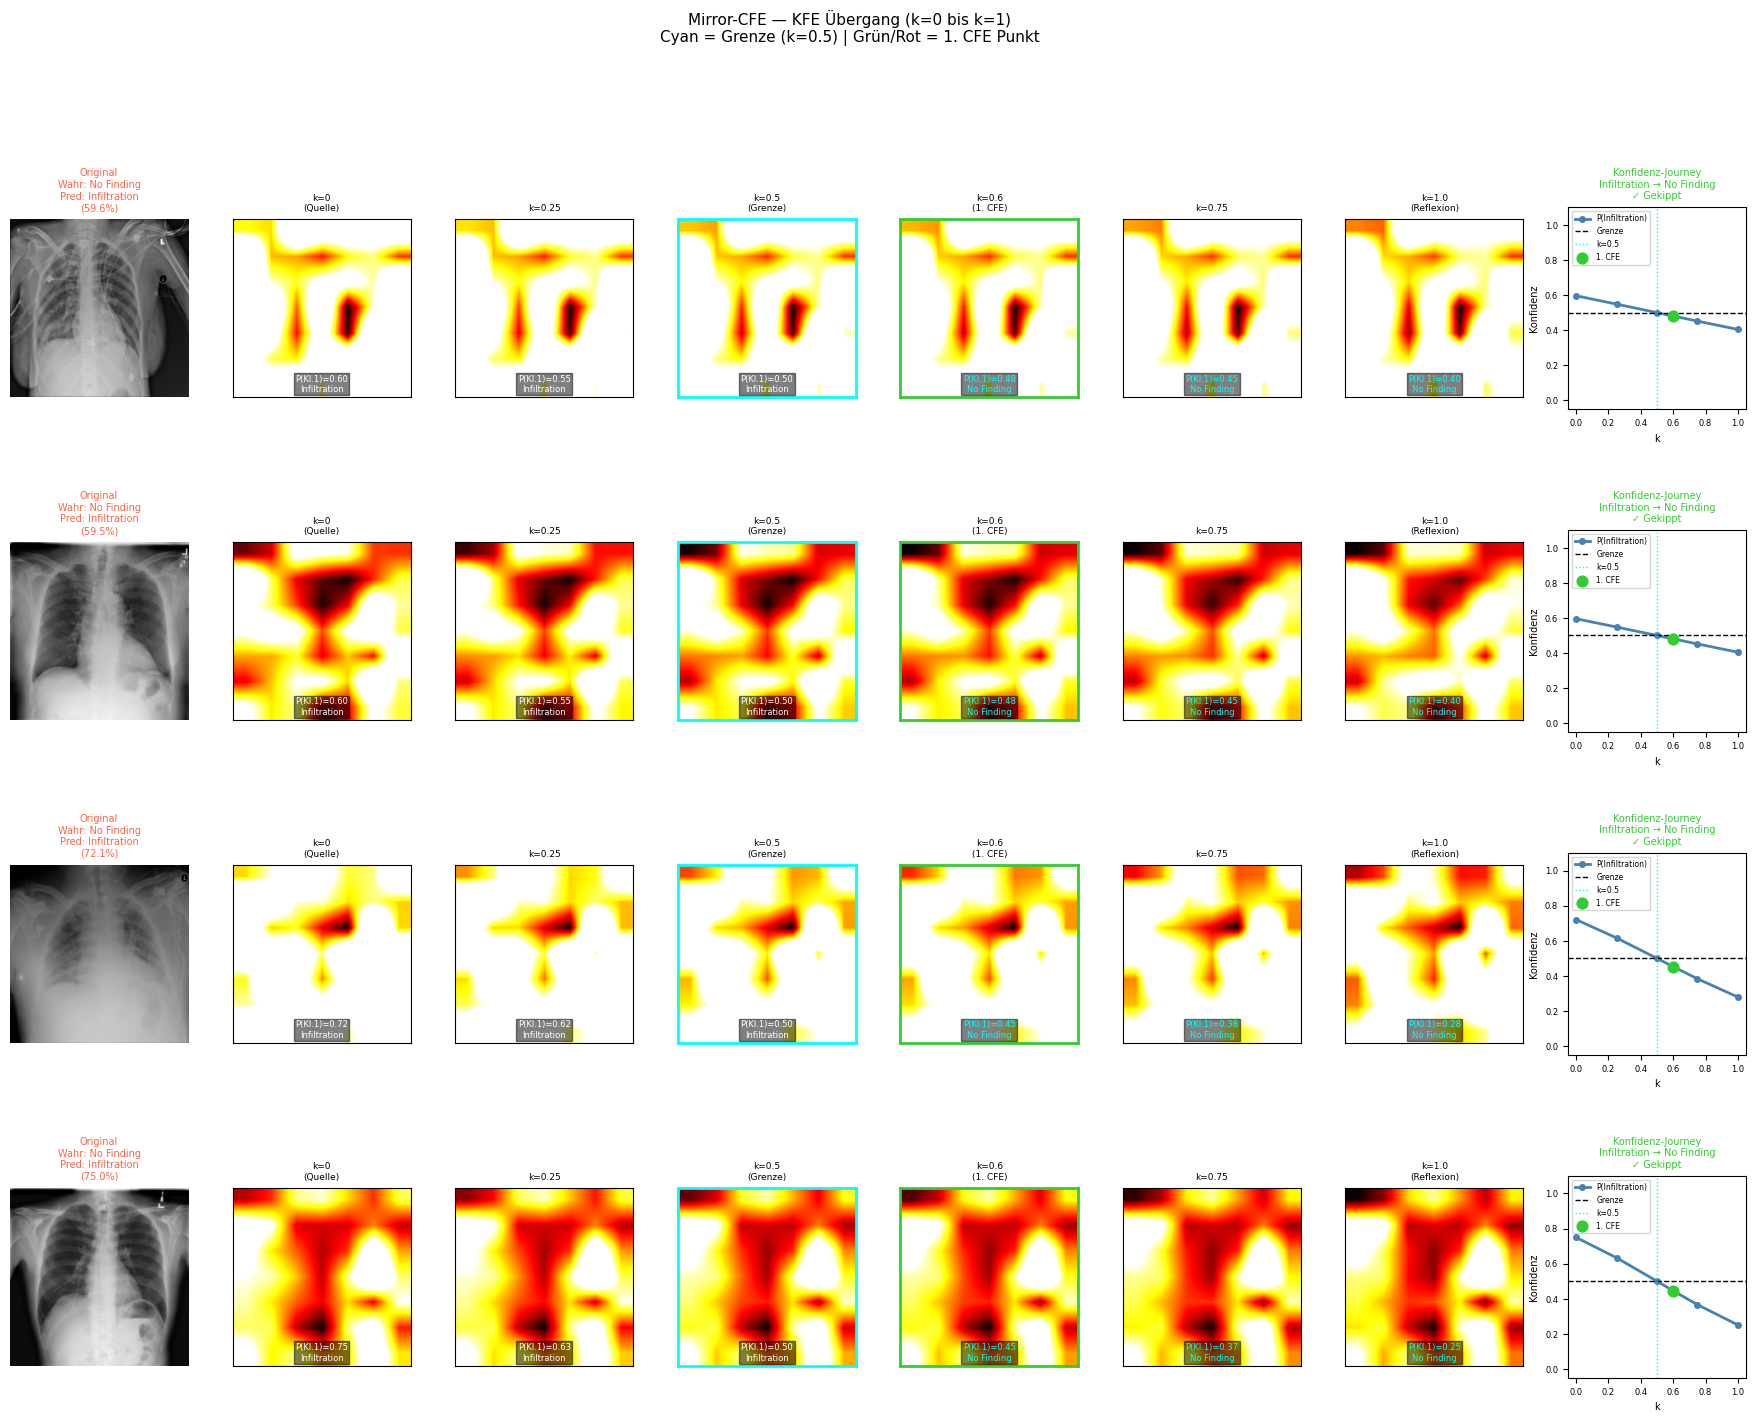

Gespeichert → /kaggle/working/mirror_cfe_xray.png


In [11]:
visualise_cfe(
    model         = model,
    images        = sample_images,
    labels        = sample_labels,
    fnames        = sample_fnames,
    mirror_fv     = mirror_fv,
    cfe_labels    = cfe_labels,
    source_labels = source_labels,
    orig_probs    = orig_probs,
    bbox_lookup   = bbox_lookup,
    class_names   = CLASS_NAMES,
    bbox_class_idx = 1,       # Infiltration hat BBoxen
    bbox_color    = 'yellow',
    n_samples     = 4,
    save_path     = '/kaggle/working/mirror_cfe_xray.png'
)

## 12. Nur Infiltration-Bilder mit BBox

Infiltration-Bilder mit BBox im Test-Set: 11


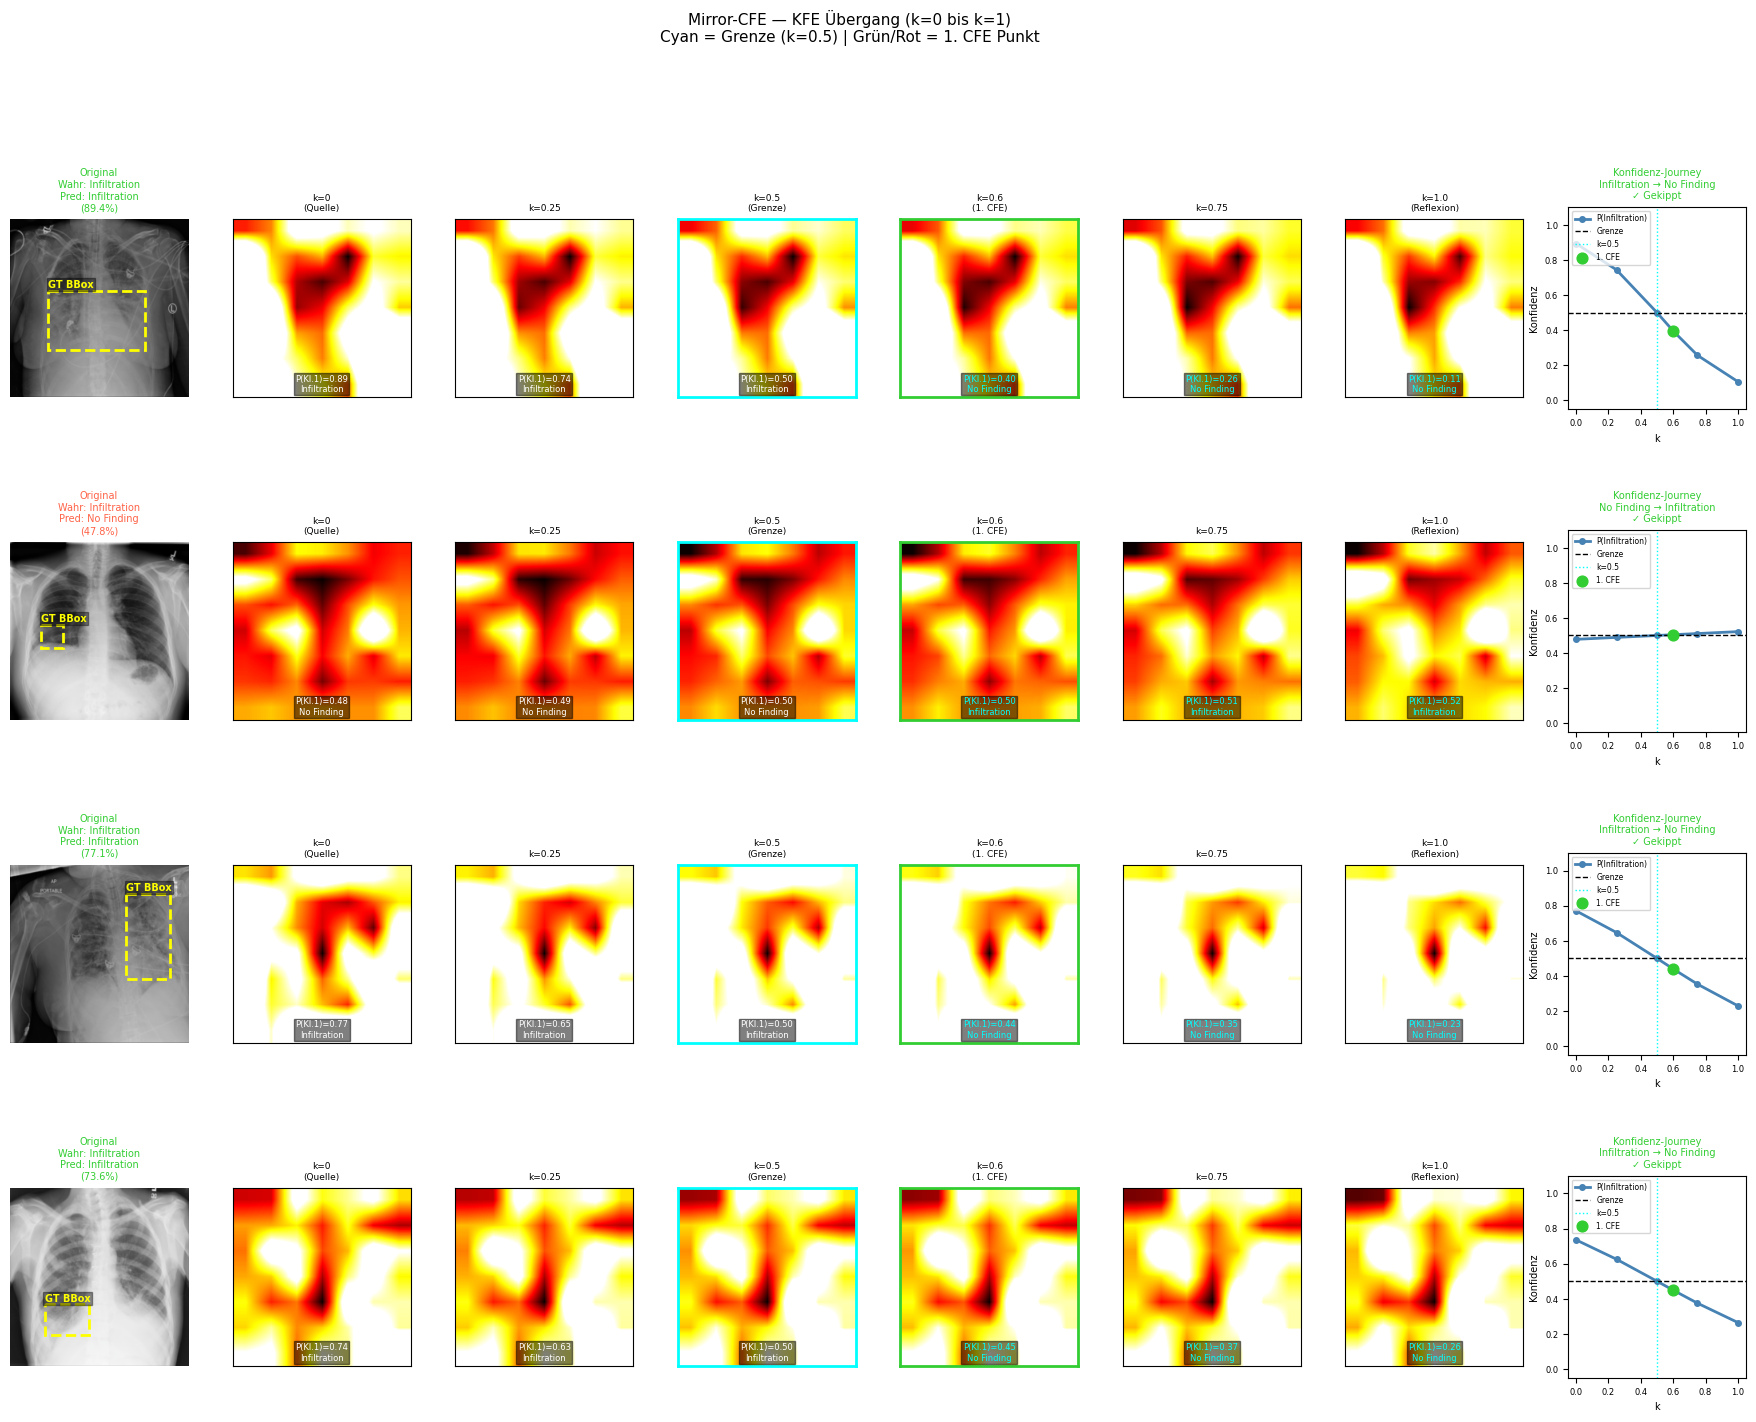

Gespeichert → /kaggle/working/mirror_cfe_xray_bbox.png


In [12]:
bbox_image_names = set(bbox_lookup.keys())
test_with_bbox = test_df[
    (test_df['binary_label'] == 1) &
    (test_df['Image Index'].isin(bbox_image_names))
].reset_index(drop=True)

print(f'Infiltration-Bilder mit BBox im Test-Set: {len(test_with_bbox)}')

if len(test_with_bbox) == 0:
    test_with_bbox = all_xray_df[
        (all_xray_df['binary_label'] == 1) &
        (all_xray_df['Image Index'].isin(bbox_image_names))
    ].reset_index(drop=True)
    print(f'Verwende alle verfügbaren BBox-Bilder: {len(test_with_bbox)}')

bbox_dataset = XRayDataset(test_with_bbox, transform=eval_transforms)
bbox_loader  = DataLoader(bbox_dataset, batch_size=8, shuffle=True,
                          num_workers=2, pin_memory=False)
bbox_imgs, bbox_lbls, bbox_fnames = next(iter(bbox_loader))
m_fv_b, cfe_b, src_b, prob_b = compute_mirror_cfe(
    model, bbox_imgs, DEVICE, num_iterations=20
)
visualise_cfe(
    model=model, images=bbox_imgs, labels=bbox_lbls, fnames=bbox_fnames,
    mirror_fv=m_fv_b, cfe_labels=cfe_b, source_labels=src_b,
    orig_probs=prob_b, bbox_lookup=bbox_lookup, class_names=CLASS_NAMES,
    bbox_class_idx=1, bbox_color='yellow', n_samples=4,
    save_path='/kaggle/working/mirror_cfe_xray_bbox.png'
)

## 13. Batch-Evaluation

In [13]:
n_batches    = 10
total_flip   = 0
total_images = 0

for batch_imgs, batch_lbls, batch_fnames in tqdm(
        list(test_loader)[:n_batches], desc='CFE Evaluation'):
    m_fv, c_lbls, s_lbls, o_probs = compute_mirror_cfe(
        model, batch_imgs, DEVICE, num_iterations=20
    )
    cfe_p = predict_from_features(model, m_fv).cpu()
    preds = (cfe_p >= 0.5).long()
    total_flip   += (preds == c_lbls.cpu()).sum().item()
    total_images += len(batch_lbls)

print(f'\nFlip Rate: {total_flip}/{total_images} = {total_flip/total_images:.2%}')

CFE Evaluation: 100%|██████████| 10/10 [00:05<00:00,  1.88it/s]


Flip Rate: 160/160 = 100.00%
